# Inspección visual de segmentaciones (sin interpretabilidad)

Este notebook carga un solo paciente/sesión y muestra todas las segmentaciones encontradas, con la misma lógica de carga que interpretability_2.py.

In [57]:
# Imports
import os
import math
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, EnsureTyped,
    ResampleToMatchd, AsDiscreted, Resized, SelectItemsd, Orientationd
)

from bimcv_prostate.data.transforms import build_image_transforms
from bimcv_prostate.utils.data_utils import apply_path_rewrites

try:
    import nibabel as nib
except Exception:
    nib = None
    print("[WARN] nibabel no disponible, no se podrán inspeccionar metadatos NIfTI.")

In [73]:
# Configuración (ajusta estos valores)
XNAT_ROOT = Path("../Files/data/validation/descargas_xnat_segura/")
DATA_CSV = "../Files/data_interpretability.csv"

# Columna de sesión en el CSV
SESSION_COLUMN = "ID_XNAT_session"

# Columnas con rutas de imagen en el CSV (ajusta si tus columnas tienen otros nombres)
CSV_IMAGE_COLUMNS = ("t2", "adc", "dwi")

# Sesión a inspeccionar (ejemplo: "XNAT03_E06835")
SESSION_ID = "XNAT03_E06230"

# Filtra por partición si aplica (ej. "val"), o pon None para no filtrar
PARTITION_FILTER = "val"

# Input shape usado por el modelo/dataloader
INPUT_SHAPE = (128, 128, 32)
ADC_PERCENTILE_SCALE = True

# Reescrituras de rutas (igual que interpretability_2.py)
PATH_REWRITES = [["ceib/", ""], ["prueba/p0052021_reborn/", "p0052021/"], ["prueba/", ""]]

# Selección de referencia: "DICOM" | "NIFTI" | "AUTO"
REF_SOURCE = "DICOM"

# Canal a mostrar en anatomía: 0=T2, 1=ADC, 2=DWI (según tus datos)
CHANNEL_TO_SHOW = 1

In [69]:
# Transformaciones para imágenes (mismas del dataloader)
image_transform = build_image_transforms(
    img_columns=CSV_IMAGE_COLUMNS,
    input_shape=INPUT_SHAPE,
    augment=False,
    adc_percentile_scale=ADC_PERCENTILE_SCALE,
    include_numeric=False,
 )

# Transformación para labels usando la misma geometría de T2 + resize al input_shape
label_transform = Compose([
    LoadImaged(keys=["t2", "label"], reader="ITKReader"),
    EnsureChannelFirstd(keys=["t2", "label"]),
    EnsureTyped(keys=["t2", "label"]),
    ResampleToMatchd(keys="label", key_dst="t2", mode="nearest", padding_mode="zeros"),
    Resized(keys=["t2", "label"], spatial_size=INPUT_SHAPE, mode=("trilinear", "nearest")),
    AsDiscreted(keys="label", threshold=0.5),
    SelectItemsd(keys=["label"]),
])

monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.


In [70]:
def list_seg_sources(seg_root: Path):
    sources = []
    if not seg_root.exists():
        return sources
    for sub in seg_root.iterdir():
        if not sub.is_dir():
            continue
        niftis = list(sub.glob("*.nii*"))
        if niftis:
            sources.extend([str(n) for n in niftis])
            continue
        dcm_files = sorted(list(sub.rglob("*.dcm")) + list(sub.rglob("*.ima")))
        if dcm_files:
            sources.append(str(dcm_files[0]))
    return sorted(list(set(sources)))

def find_scan_folders_with_seg(session_dir: Path) -> List[Path]:
    scans = [p for p in session_dir.iterdir() if p.is_dir()]
    if not scans:
        raise FileNotFoundError(f"No hay scans en: {session_dir}")
    return [s for s in scans if (s / "SEGMENTATION").exists()]

def list_all_seg_sources(session_dir: Path) -> List[Tuple[str, str]]:
    scans_with_seg = find_scan_folders_with_seg(session_dir)
    all_sources: List[Tuple[str, str]] = []
    for scan_folder in scans_with_seg:
        seg_root = scan_folder / "SEGMENTATION"
        sources = list_seg_sources(seg_root)
        for src in sources:
            all_sources.append((scan_folder.name, src))
    return all_sources

def get_case_row(session_id: str):
    df = pd.read_csv(DATA_CSV)
    apply_path_rewrites(df, list(CSV_IMAGE_COLUMNS), PATH_REWRITES)
    if PARTITION_FILTER is not None and "partition" in df.columns:
        df = df[df["partition"] == PARTITION_FILTER].reset_index(drop=True)
    if SESSION_COLUMN not in df.columns:
        raise KeyError(f"No existe la columna {SESSION_COLUMN} en el CSV")
    sel = df[df[SESSION_COLUMN].astype(str) == str(session_id)]
    if sel.empty:
        raise ValueError(f"No se encontró {session_id} en {SESSION_COLUMN}")
    return sel.iloc[0]

def load_image_from_row(row):
    # build_image_transforms espera dict con keys t2/adc/dwi y un label (dummy)
    sample = {
        "t2": row[CSV_IMAGE_COLUMNS[0]],
        "adc": row[CSV_IMAGE_COLUMNS[1]],
        "dwi": row[CSV_IMAGE_COLUMNS[2]],
        "label": torch.zeros(2),
    }
    out = image_transform(sample)
    return out["image"]

def load_label_for_seg(seg_path: str, t2_path: str):
    out = label_transform({"t2": t2_path, "label": seg_path})
    return (out["label"] > 0)

def get_nifti_meta(path: str):
    if nib is None:
        return None
    try:
        img = nib.load(path)
        return {
            "shape": img.shape,
            "zoom": img.header.get_zooms(),
            "affine": img.affine,
        }
    except Exception as e:
        print(f"[WARN] No se pudo leer metadatos NIfTI {path}: {e}")
        return None

def compare_nifti_meta(t2_path: str, seg_path: str):
    t2_meta = get_nifti_meta(t2_path)
    seg_meta = get_nifti_meta(seg_path)
    if t2_meta is None or seg_meta is None:
        return
    print("\n[INFO] Comparación espacial (NIfTI):")
    print(f"  T2  shape={t2_meta['shape']} zoom={t2_meta['zoom']}")
    print(f"  SEG shape={seg_meta['shape']} zoom={seg_meta['zoom']}")
    print(f"  T2  affine=\n{t2_meta['affine']}")
    print(f"  SEG affine=\n{seg_meta['affine']}")

def plot_reference_overlay(seg_path: str, t2_path: str, channel: int = 0, slice_index: int = None):
    if nib is None:
        print("[WARN] nibabel no disponible, no se puede graficar referencia.")
        return
    try:
        t2_img = nib.load(t2_path)
        seg_img = nib.load(seg_path)
        t2 = t2_img.get_fdata()
        seg = seg_img.get_fdata()
    except Exception as e:
        print(f"[WARN] No se pudo cargar NIfTI para referencia: {e}")
        return
    if t2.ndim == 4:
        t2 = t2[..., channel]
    if seg.ndim > 3:
        seg = seg[..., 0]
    z = slice_index if slice_index is not None else t2.shape[2] // 2
    z = min(z, t2.shape[2] - 1)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(t2[:, :, z], cmap="gray")
    ax.contour(seg[:, :, z] > 0, colors="red", linewidths=1.5)
    ax.set_title(f"Referencia NIfTI (slice {z})")
    ax.axis("off")
    plt.show()

def load_all_segmentations(session_dir: Path, row):
    seg_sources = list_all_seg_sources(session_dir)
    if not seg_sources:
        raise FileNotFoundError(f"No hay segmentaciones en {session_dir}")

    print(f"[INFO] Total segmentaciones encontradas: {len(seg_sources)}")
    for i, (scan_name, src) in enumerate(seg_sources, start=1):
        print(f"[INFO] {i}/{len(seg_sources)} [{scan_name}]: {src}")

    image = load_image_from_row(row)
    t2_path = row[CSV_IMAGE_COLUMNS[0]]

    loaded = []
    for scan_name, seg_path in seg_sources:
        try:
            label = load_label_for_seg(seg_path, t2_path)
        except Exception as e:
            print(f"[WARN] No se pudo cargar {seg_path}: {e}")
            continue
        loaded.append({
            "scan": scan_name,
            "seg_path": seg_path,
            "image": image,
            "label": label
        })
    if len(loaded) == 0:
        raise RuntimeError("No se pudo cargar ninguna segmentación.")
    return loaded

In [71]:
def plot_all_segmentations(loaded, channel=1, every_n=1, max_cols=6):
    if len(loaded) == 0:
        print("No hay segmentaciones para mostrar.")
        return

    ref = loaded[0]
    img = ref["image"][channel].cpu().numpy()  # (H, W, D)
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (2, 0, 1))  # (D, H, W)

    masks = [np.transpose(d["label"].squeeze(0).cpu().numpy(), (2, 0, 1)) for d in loaded]
    labels = [d.get("seg_path", f"seg_{i}") for i, d in enumerate(loaded, start=1)]

    colors = ["lime", "cyan", "yellow", "magenta", "orange", "red", "blue", "white"]
    color_map = [colors[i % len(colors)] for i in range(len(masks))]

    print("\n[INFO] Mapeo color -> segmentación:")
    for i, label in enumerate(labels):
        print(f"  {color_map[i]} -> {label}")

    num_slices = img.shape[0]
    indices = list(range(0, num_slices, every_n))
    n_plots = len(indices)
    cols = max_cols
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(22, 3.5 * rows))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        ax.imshow(img[idx], cmap="gray")

        any_contour = False
        for k, m in enumerate(masks):
            if m[idx].max() > 0:
                ax.contour(m[idx], colors=color_map[k], linewidths=1.8, levels=[0.5])
                any_contour = True
        if any_contour:
            ax.set_title(f"Slice {idx} [GT x{len(masks)}]", fontsize=10, color="green")
        else:
            ax.set_title(f"Slice {idx}", fontsize=10)
        ax.axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

[INFO] Total segmentaciones encontradas: 2
[INFO] 1/2 [scan_703]: ../Files/data/validation/descargas_xnat_segura/XNAT03_E06230/scan_703/SEGMENTATION/1889553/SEG_20251124_105025_046_S703.dcm
[INFO] 2/2 [scan_901]: ../Files/data/validation/descargas_xnat_segura/XNAT03_E06230/scan_901/SEGMENTATION/1889552/SEG_20251124_104819_293_S901.dcm
Ejemplo 1:
  scan: scan_703
  seg_path: ../Files/data/validation/descargas_xnat_segura/XNAT03_E06230/scan_703/SEGMENTATION/1889553/SEG_20251124_105025_046_S703.dcm
  image shape: (3, 128, 128, 32)
  label shape: (1, 128, 128, 32)
[WARN] No se pudo leer metadatos NIfTI ../Files/data/validation/descargas_xnat_segura/XNAT03_E06230/scan_703/SEGMENTATION/1889553/SEG_20251124_105025_046_S703.dcm: Cannot work out file type of "../Files/data/validation/descargas_xnat_segura/XNAT03_E06230/scan_703/SEGMENTATION/1889553/SEG_20251124_105025_046_S703.dcm"
[WARN] No se pudo cargar NIfTI para referencia: Cannot work out file type of "../Files/data/validation/descargas_x

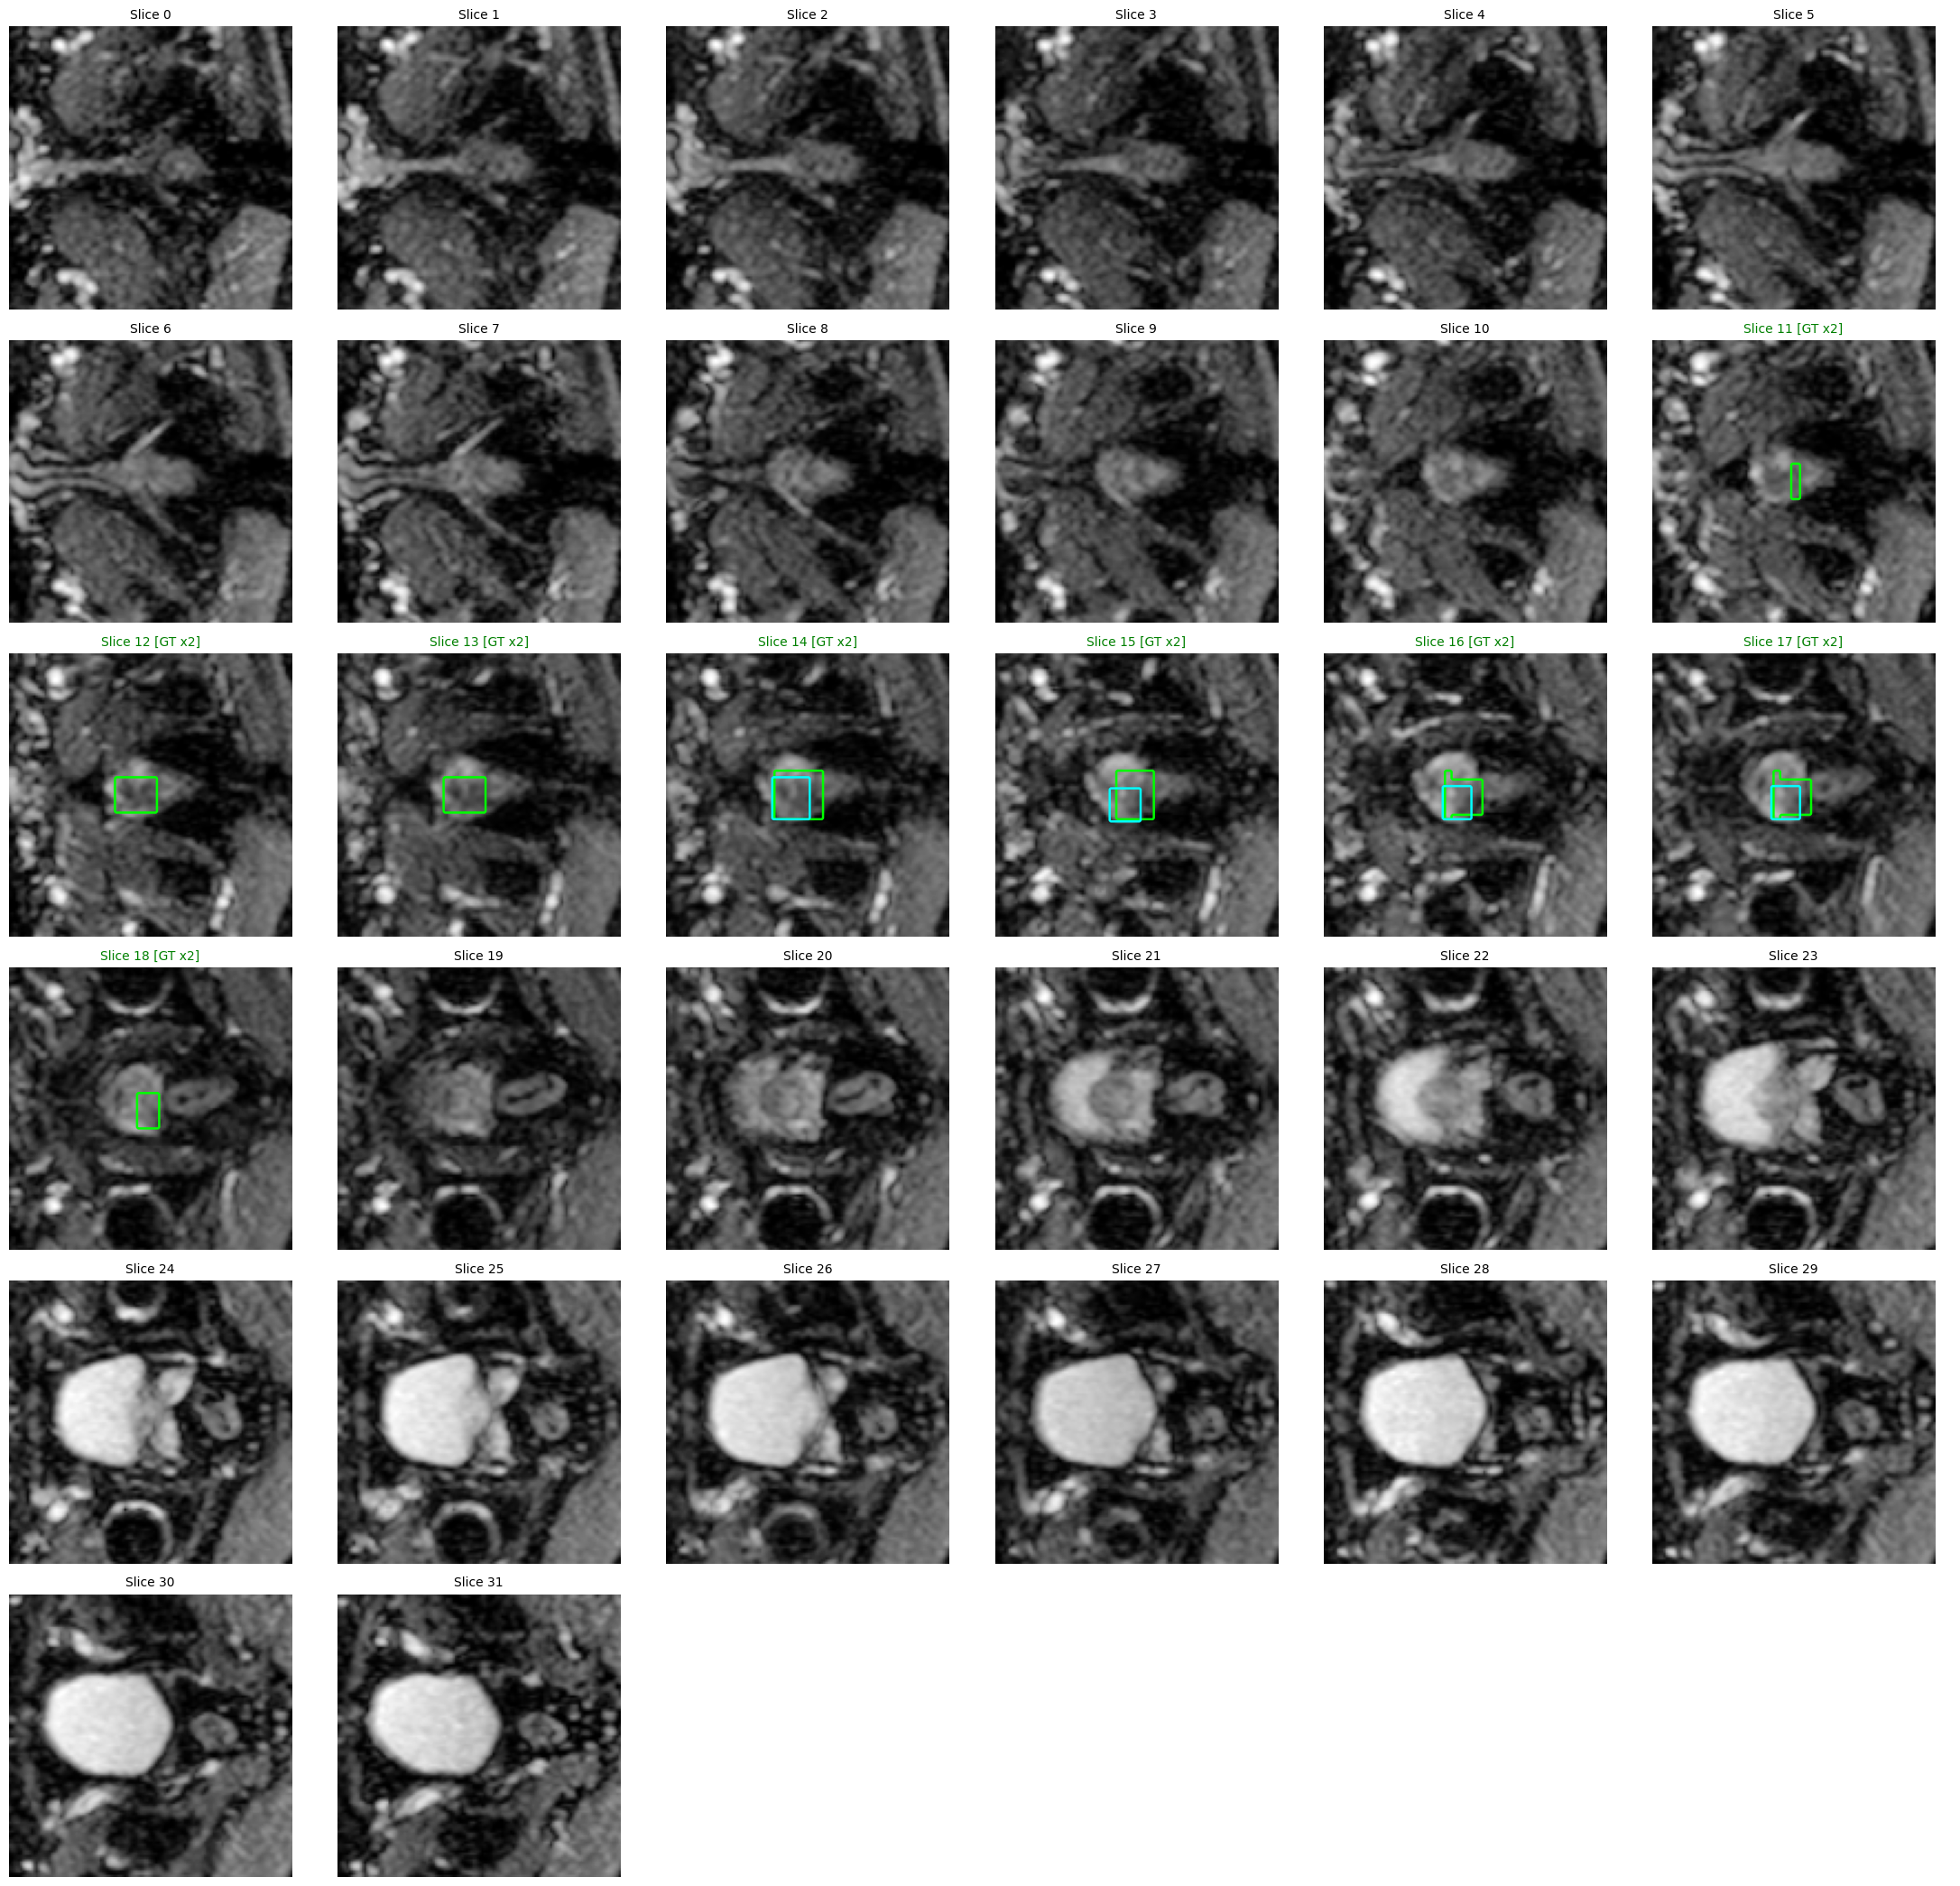

In [74]:
# Ejecutar la inspección para una sesión
session_dir = XNAT_ROOT / SESSION_ID
row = get_case_row(SESSION_ID)
loaded = load_all_segmentations(session_dir, row)

# Opcional: validar que cada seg está alineada a su imagen de origen
print("Ejemplo 1:")
print("  scan:", loaded[0]["scan"])
print("  seg_path:", loaded[0]["seg_path"])
print("  image shape:", tuple(loaded[0]["image"].shape))
print("  label shape:", tuple(loaded[0]["label"].shape))

# Comparación espacial con NIfTI de referencia (si está disponible)
compare_nifti_meta(row[CSV_IMAGE_COLUMNS[0]], loaded[0]["seg_path"])
plot_reference_overlay(loaded[0]["seg_path"], row[CSV_IMAGE_COLUMNS[0]], channel=CHANNEL_TO_SHOW)

# Visualización de contornos (todas las segmentaciones sobre la anatomía del dataloader)
plot_all_segmentations(loaded, channel=CHANNEL_TO_SHOW, every_n=1)